# 03 - Analiza danych

1. Czy występuje różnica czasu przejazdu w kierunku A oraz B? Jeśli tak, w jakich godzinach jest realnie widoczna?
2. Czy pogoda wpływa realnie na czas przejazdu? Jaka jest korelacja pomiędzy kolumnami Weather_Conditions a Duration_Min?
3. Która z tras ma najniższy średni czas, a na której mamy większą pewność że długość przejazdu znacznie się nie odchyli?
4. O których godzinach czas przejazdu jest minimalny, a kiedy maksymalny? Czy są to codziennie te same pory?
5. Czy weekend znacznie wpływa na czas przejazdu? 

## 1. Import i wczytanie danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/processed/traveltime_clean.csv')
print(df.shape)
print(df.columns)

(44588, 18)
Index(['Measurement_Id', 'Route_Id', 'Direction', 'Date', 'Day_Of_Week',
       'Measurement_Time', 'Duration_Min', 'Delay_Min', 'Weather_Origin',
       'Temperature_Origin', 'Humidity_Origin', 'Rain_Origin',
       'Visibility_Origin', 'Weather_Destination', 'Temperature_Destination',
       'Humidity_Destination', 'Rain_Destination', 'Visibility_Destination'],
      dtype='str')


---

## Pytanie 1 - Czy występuje różnica czasu przejazdu w kierunku A oraz B? 

**Hipoteza:** kierunek A (do Katowic) jest wolniejszy rano, kierunek B (do Tarnowskich Gór) wolniejszy po południu.

In [3]:
trasa_A = df[df['Direction'] == 'A']['Duration_Min']
trasa_B = df[df['Direction'] == 'B']['Duration_Min']

print("Minimalna wartość Duration_Min:")
print("Trasa A:", trasa_A.min(), "\nTrasa B:", trasa_B.min())

print("\nŚrednia wartość Duration_Min:")
print("Trasa A:", trasa_A.mean().round(2), "\nTrasa B:", trasa_B.mean().round(2))

print("\nMaksymalna wartość Duration_Min:")
print("Trasa A:", trasa_A.max(), "\nTrasa B:", trasa_B.max())

print("\n Odchylenie standardowe Duration_Min:")
print("Trasa A:", trasa_A.std().round(2), "\nTrasa B:", trasa_B.std().round(2))

Minimalna wartość Duration_Min:
Trasa A: 35.0 
Trasa B: 32.0

Średnia wartość Duration_Min:
Trasa A: 44.97 
Trasa B: 42.26

Maksymalna wartość Duration_Min:
Trasa A: 76.0 
Trasa B: 86.0

 Odchylenie standardowe Duration_Min:
Trasa A: 5.31 
Trasa B: 6.46


Okazuje się że trasy B (Katowice -> Tarnowskie Góry) mają krótszy zarówno czas minimalny jak i średni. Maksymalny czas jest jednak znacznie krótszy w trasach A, jest to różnica 10 minut. Odchylenie standardowe jest większe o ponad minutę dla tras B.

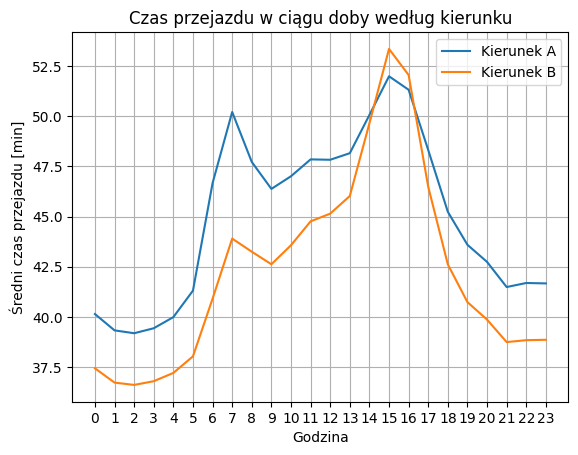

In [4]:
df['Hour'] = pd.to_datetime(df['Measurement_Time'], format='%H:%M').dt.hour
hourly = df.groupby(['Hour', 'Direction'])['Duration_Min'].mean().reset_index()

plt.plot(hourly[hourly['Direction'] == 'A']['Hour'], hourly[hourly['Direction'] == 'A']['Duration_Min'])
plt.plot(hourly[hourly['Direction'] == 'B']['Hour'], hourly[hourly['Direction'] == 'B']['Duration_Min'])
plt.xlabel('Godzina')
plt.ylabel('Średni czas przejazdu [min]')
plt.xticks(range(0, 24))
plt.title('Czas przejazdu w ciągu doby według kierunku')
plt.legend(['Kierunek A', 'Kierunek B'])
plt.grid()
plt.show()

**Wniosek:** Trasa A jest widocznie dłuższa od rana aż do 14:00 gdzie Trasa B staje się dłuższa, aż do godziny 16:00. 

---

## Pytanie 2 - Czy pogoda wpływa na czas przejazdu?

**Hipoteza:** wzrost temperatury oraz opady powodują wydłużenie czasu przejazdu.

Mamy łącznie 10 kolumn dotyczących warunków pogodowych, po 5 dla origin i destination.

In [5]:
print("Korealacja Duration_Min z zmiennymi pogodowymi:")
pogoda_numeryczne = df[['Duration_Min', 'Temperature_Origin', 'Temperature_Destination', 'Humidity_Origin', 'Humidity_Destination', 'Rain_Origin', 'Rain_Destination', 'Visibility_Origin', 'Visibility_Destination']]
corr_matrix = pogoda_numeryczne.corr()
print(corr_matrix['Duration_Min'].round(2).sort_values(ascending=False))

Korealacja Duration_Min z zmiennymi pogodowymi:
Duration_Min               1.00
Temperature_Destination    0.33
Temperature_Origin         0.32
Visibility_Destination     0.03
Rain_Destination           0.03
Rain_Origin                0.02
Visibility_Origin          0.02
Humidity_Destination      -0.33
Humidity_Origin           -0.34
Name: Duration_Min, dtype: float64


Widać tutaj że największą korelację z Duration_Min mają zmienne Humidity oraz Temperature. Tworzę heatmapę aby to zwizualizować.

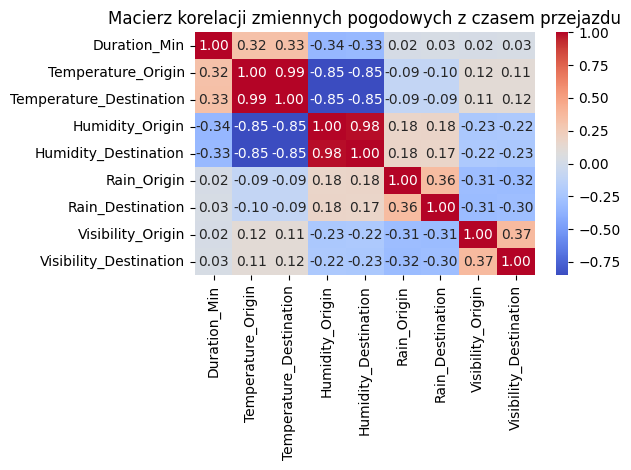

In [6]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Macierz korelacji zmiennych pogodowych z czasem przejazdu')
plt.tight_layout()
plt.show()

Na tej wizualizacji oprócz wniosków powyżej możemy też zauważyć że same zmienne Humidity i Temperature mają wysoką korelację między sobą: -0.85. Co ciekawe, Rain oraz Visibility mają skrajnie małe korelacje z Duration_Min.

count    44588.000000
mean        19.480179
std          4.597368
min         10.000000
25%         15.990000
50%         18.770000
75%         22.490000
max         33.280000
Name: Temperature_Origin, dtype: float64


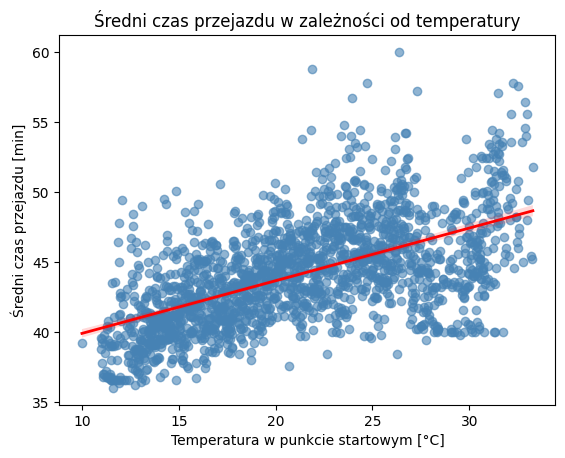

In [7]:
print(df['Temperature_Origin'].describe())

temperature_grouped = df.groupby('Temperature_Origin')['Duration_Min'].mean().reset_index()
sns.regplot(x='Temperature_Origin', y='Duration_Min', data=temperature_grouped, 
scatter_kws={'color': 'steelblue', 'alpha': 0.6},
line_kws={'color': 'red', 'linewidth': 2})
plt.xlabel('Temperatura w punkcie startowym [°C]')
plt.ylabel('Średni czas przejazdu [min]')
plt.title('Średni czas przejazdu w zależności od temperatury')
plt.show()  

In [8]:
print(df['Rain_Origin'].describe())

df['Rain_Category'] = pd.cut(df['Rain_Origin'],
                              bins=[-0.1, 0, 2, 10, 50],
                              labels=['Brak (0mm)', 'Słaby (0-2mm)', 
                                      'Umiarkowany (2-10mm)', 'Silny (10mm+)'])

print(df['Rain_Category'].value_counts())

count    44588.000000
mean         0.351432
std          1.590778
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         42.110000
Name: Rain_Origin, dtype: float64
Rain_Category
Brak (0mm)              37459
Słaby (0-2mm)            4879
Umiarkowany (2-10mm)     2035
Silny (10mm+)             215
Name: count, dtype: int64


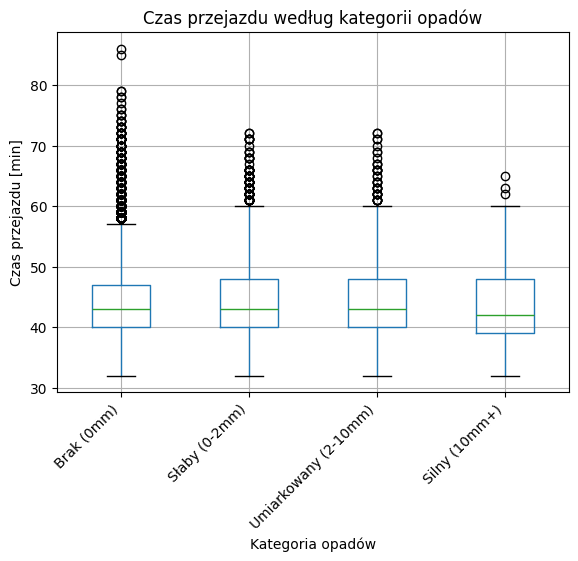

In [9]:
df.boxplot(column='Duration_Min', by='Rain_Category')
plt.xlabel('Kategoria opadów')
plt.ylabel('Czas przejazdu [min]')
plt.title('Czas przejazdu według kategorii opadów') 
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.show()

**Wniosek:** Temperatura ma znaczny wpływ na czas przejazdu, jej wzrost powoduje widoczne wydłużenie czasu przejazdu. Natomiast opady, wbrew intuicji okazały się w tym zbiorze mieć marginalny wpływ na czas przejazdu. Warto podkreślić że ilość rekordów z opadami "silnymi" określonymi w zbiorze jako +10mm było jedynie 215, podczas gdy tych z brakiem opadów aż 37459.

---

## Pytanie 3 - Która trasa jest najkrótsza i najbardziej przewidywalna?

**Hipoteza:** najkrótsza trasa nie zawsze jest najlepsza.

In [10]:
stats = df.groupby(['Route_Id', 'Direction'])['Duration_Min'].agg(['min','mean', 'max', 'std']).round(2)
print(stats[stats.index.get_level_values('Direction') == 'A'])


                     min   mean   max   std
Route_Id Direction                         
1        A          40.0  44.58  62.0  3.52
2        A          37.0  44.04  76.0  5.78
3        A          35.0  41.94  60.0  4.74
4        A          40.0  46.65  62.0  4.67
5        A          41.0  47.63  75.0  5.56


Jeśli chodzi o trasę A, najkrótszy czas przejazdu ma trasa 3, jest to jedynie 35 minut. Średni czas przejazdu także najniższy ma trasa 3, około 42 minuty. Okazuje się jednak że ma ona trochę większe odchylenie standardowe niż np. trasa 1 czy 4. Zobaczmy jak to wygląda na wykresie.

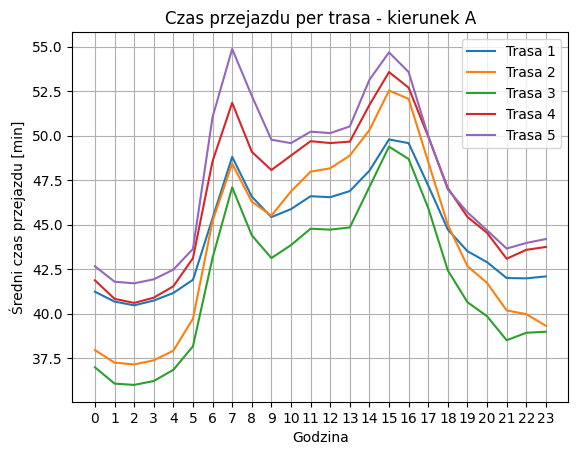

In [11]:
hourly = df.groupby(['Hour', 'Direction', 'Route_Id'])['Duration_Min'].mean().reset_index()

for route_id in sorted(df['Route_Id'].unique()):
    subset = hourly[(hourly['Direction'] == 'A') & (hourly['Route_Id'] == route_id)]
    plt.plot(subset['Hour'], subset['Duration_Min'], label=f'Trasa {route_id}')

plt.xlabel('Godzina')
plt.ylabel('Średni czas przejazdu [min]')
plt.xticks(range(0, 24))
plt.title('Czas przejazdu per trasa - kierunek A')
plt.legend()
plt.grid()
plt.show()


In [12]:
stats = df.groupby(['Route_Id', 'Direction'])['Duration_Min'].agg(['min','mean', 'max', 'std']).round(2)
print(stats[stats.index.get_level_values('Direction') == 'B'])


                     min   mean   max   std
Route_Id Direction                         
1        B          37.0  41.38  74.0  3.78
2        B          32.0  38.33  72.0  6.35
3        B          34.0  40.66  72.0  6.26
4        B          38.0  44.55  68.0  5.00
5        B          39.0  46.35  86.0  7.00


Jeśli chodzi o trasę B, najkrótszy czas przejazdu ma trasa 2, są to jedynie 32 minuty. Średni czas przejazdu także najniższy ma trasa 2, około 38 minut. Podobnie jak w przypadku kierunku "A" ma ona znacznie większe odchylenia standardowe niż np. trasa 1 lub 3. Trasa 1 okazuje się tutaj najbardziej "przewidywalna" z średnimi odchyleniami ok. 3,8 minuty.

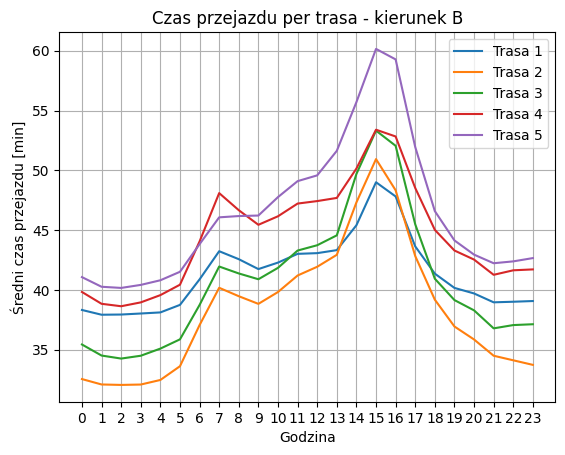

In [13]:
hourly = df.groupby(['Hour', 'Direction', 'Route_Id'])['Duration_Min'].mean().reset_index()

for route_id in sorted(df['Route_Id'].unique()):
    subset = hourly[(hourly['Direction'] == 'B') & (hourly['Route_Id'] == route_id)]
    plt.plot(subset['Hour'], subset['Duration_Min'], label=f'Trasa {route_id}')

plt.xlabel('Godzina')
plt.ylabel('Średni czas przejazdu [min]')
plt.xticks(range(0, 24))
plt.title('Czas przejazdu per trasa - kierunek B')
plt.legend()
plt.grid()
plt.show()


Ciekawa sprawa - trasy znacznie różnią się od siebie w zależności od kierunku. Jeśli chodzi o kierunek A, bezsprzecznie średnią czasu wygrywa trasa nr. 3 (Przez Piekary). Kierunek B natomiast ma trochę bardziej zawiłą sytuację - w godzinach nocnych i porannych, aż do 13:00 bezsprzecznie wygrywa trasa 2 (Przez Bytom), w godzinach 13:00 - 16:00 lepiej wypada trasa 1 (Przez Gliwice). 

**Wnioski:**
Trasa A wydaje się mieć zwycięzcę w postaci trasy 3 - posiada najmniejszy czas minimalny, czas średni oraz czas maksymalny, kolejno 35.0, 41.94 oraz 60.0 minut, z odchyleniem standardowym równym 4.74.

Trasa B pokazuje nam troszkę bardziej różnorodne wyniki: Trasa 2 wygrywa przez znaczną część doby, natomiast w godzinach szczytu (13:00-16:00) warto rozważyć trasę 1. Trasa 2 pomimo najniższego czasu minimalnego oraz średniego, przegrywa z trasą 1 pod względem odchyleń standardowych, gdzie trasa 1 wygrywa o niemal 3 minuty.

Co ciekawe, najniższy średni czas maksymalny nie należy ani do trasy 1 ani drugiej, a do trasy 4 (Przez Siemianowice Śląskie) która w tym zbiorze nie przekracza 68 minut.

---

## Pytanie 4 - O których godzinach jest najlepiej i najgorzej jechać?

**Hipoteza:** szczyt poranny ok. 7–9, szczyt popołudniowy ok. 15–17.

In [14]:
stats_A = df[df['Direction'] == 'A'].groupby('Hour').agg({'Duration_Min': 'mean', 'Delay_Min': 'mean'}).reset_index()
stats_B = df[df['Direction'] == 'B'].groupby('Hour').agg({'Duration_Min': 'mean', 'Delay_Min': 'mean'}).reset_index()

stats_A['Duration_Rank_A'] = stats_A['Duration_Min'].rank(method='min')
stats_B['Duration_Rank_B'] = stats_B['Duration_Min'].rank(method='min')

print("3 najlepsze godziny pod względem Duration_Min dla trasy A:")
print(stats_A.nsmallest(3, 'Duration_Rank_A')[['Hour', 'Duration_Min']])
print("\n3 najgorsze godziny pod względem Duration_Min dla trasy A:")
print(stats_A.nlargest(3, 'Duration_Rank_A')[['Hour', 'Duration_Min']])

print("\n3 najlepsze godziny pod względem Duration_Min dla trasy B:")
print(stats_B.nsmallest(3, 'Duration_Rank_B')[['Hour', 'Duration_Min']])
print("\n3 najgorsze godziny pod względem Duration_Min dla trasy B:")
print(stats_B.nlargest(3, 'Duration_Rank_B')[['Hour', 'Duration_Min']])



3 najlepsze godziny pod względem Duration_Min dla trasy A:
   Hour  Duration_Min
2     2     39.182796
1     1     39.324731
3     3     39.431183

3 najgorsze godziny pod względem Duration_Min dla trasy A:
    Hour  Duration_Min
15    15     51.994624
16    16     51.322581
7      7     50.212903

3 najlepsze godziny pod względem Duration_Min dla trasy B:
   Hour  Duration_Min
2     2     36.605376
1     1     36.720430
3     3     36.791398

3 najgorsze godziny pod względem Duration_Min dla trasy B:
    Hour  Duration_Min
15    15     53.359140
16    16     52.058065
14    14     49.649462


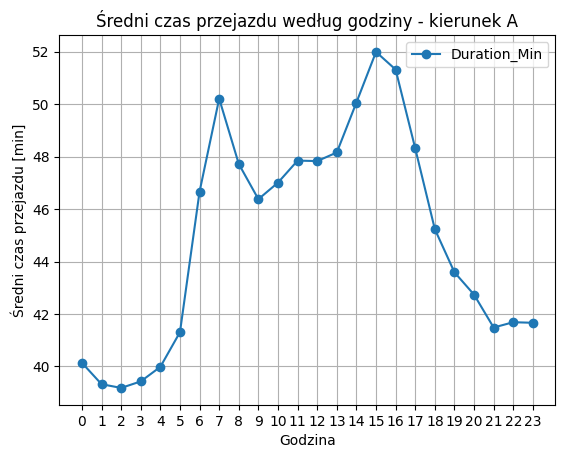

In [15]:
stats_A.plot(x='Hour', y='Duration_Min', kind='line', marker='o')
plt.xlabel('Godzina')
plt.ylabel('Średni czas przejazdu [min]')
plt.title('Średni czas przejazdu według godziny - kierunek A')
plt.xticks(range(0, 24))
plt.grid()
plt.show()

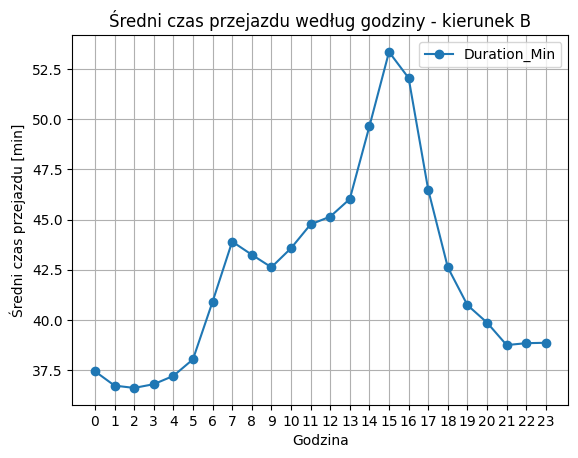

In [16]:
stats_B.plot(x='Hour', y='Duration_Min', kind='line', marker='o')
plt.xlabel('Godzina')
plt.ylabel('Średni czas przejazdu [min]')
plt.title('Średni czas przejazdu według godziny - kierunek B')
plt.xticks(range(0, 24))
plt.grid()
plt.show()

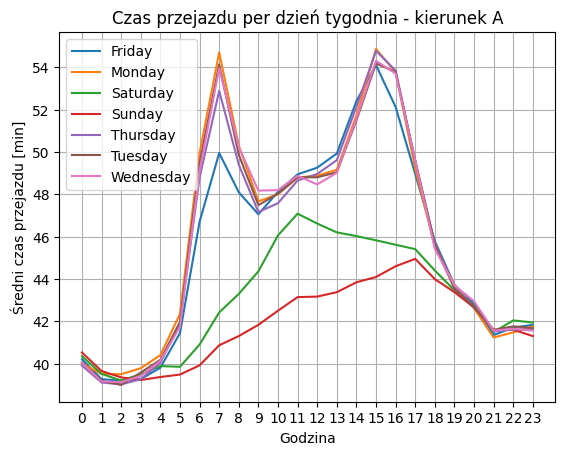

In [17]:
hourly = df.groupby(['Hour', 'Direction', 'Day_Of_Week'])['Duration_Min'].mean().reset_index()

for day in sorted(df['Day_Of_Week'].unique()):
    subset = hourly[(hourly['Direction'] == 'A') & (hourly['Day_Of_Week'] == day)]
    plt.plot(subset['Hour'], subset['Duration_Min'], label=f'{day}')

plt.xlabel('Godzina')
plt.ylabel('Średni czas przejazdu [min]')
plt.xticks(range(0, 24))
plt.title('Czas przejazdu per dzień tygodnia - kierunek A')
plt.legend()
plt.grid()
plt.show()



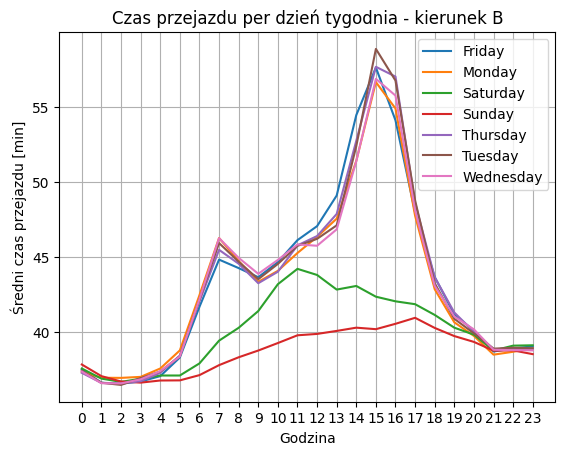

In [18]:
hourly = df.groupby(['Hour', 'Direction', 'Day_Of_Week'])['Duration_Min'].mean().reset_index()

for day in sorted(df['Day_Of_Week'].unique()):
    subset = hourly[(hourly['Direction'] == 'B') & (hourly['Day_Of_Week'] == day)]
    plt.plot(subset['Hour'], subset['Duration_Min'], label=f'{day}')

plt.xlabel('Godzina')
plt.ylabel('Średni czas przejazdu [min]')
plt.xticks(range(0, 24))
plt.title('Czas przejazdu per dzień tygodnia - kierunek B')
plt.legend()
plt.grid()
plt.show()



**Wniosek:** W tej analizie na pierwszy plan wybija się różnica pomiędzy trasami A i B w godzinach porannych. Okazuje się że w godzinach 6 - 9 w kierunku A możemy zauważyć bardzo mocne opóźnienia, natomiast o tej samej porze na w kierunku B widać jedynie lekki wzrost czasu przejazdu. Obydwia kierunki natomiast mają wspólne dwie godziny jeśli chodzi o maksymalny czas przejazdu - 15 oraz 16 - są to absolutni zwycięzcy jeśli chodzi o maksymalny czas przejazdu.

Czy są to codziennie te same pory? Prawie. W dni robocze wzorzec jest spójny - szczyt poranny około 6:00-9:00 i popołudniowy około 15:00-16:00. W weekendy te szczyty praktycznie znikają , co potwierdza że są spowodowane dojazdem i powrotem ludzi z pracy, uczelni.

---

## Pytanie 5 - Czy weekend wpływa na czas przejazdu?

**Hipoteza:** w weekendy ruch jest mniejszy, czasy przejazdu krótsze.

In [19]:
df['Date'] = pd.to_datetime(df['Date'])
df['Is_Weekend'] = df['Date'].dt.dayofweek >= 5

In [20]:
print(df.groupby('Day_Of_Week')['Duration_Min'].describe().round(2).sort_values(by='mean'))

              count   mean   std   min   25%   50%   75%   max
Day_Of_Week                                                   
Sunday       5758.0  40.32  3.42  32.0  38.0  41.0  43.0  60.0
Saturday     5759.0  41.59  3.90  32.0  39.0  42.0  44.0  57.0
Friday       5759.0  44.40  6.36  32.0  40.0  44.0  48.0  79.0
Wednesday    7200.0  44.53  6.35  32.0  40.0  44.0  49.0  72.0
Thursday     7152.0  44.55  6.56  32.0  40.0  44.0  49.0  86.0
Monday       5760.0  44.56  6.38  32.0  40.0  44.0  49.0  76.0
Tuesday      7200.0  44.62  6.53  32.0  40.0  44.0  49.0  78.0


Najniższy średni czas przejazdu ma niedziela, ok. 40 minut, maksymalny czas natomiast w czwartek, aż 86 minut.
W weekendy znacznie obniższa się także odchylenie standardowe czasu przejazdu - z ok. 6 minut w tygodniu aż do 3,5 minuty. 

In [21]:
print("Average Duration_Min and Delay_Min by Is_Weekend:")
print(df.groupby('Is_Weekend')[['Duration_Min', 'Delay_Min']].mean().round(2))


Average Duration_Min and Delay_Min by Is_Weekend:
            Duration_Min  Delay_Min
Is_Weekend                         
False              44.54       7.34
True               40.96       3.76


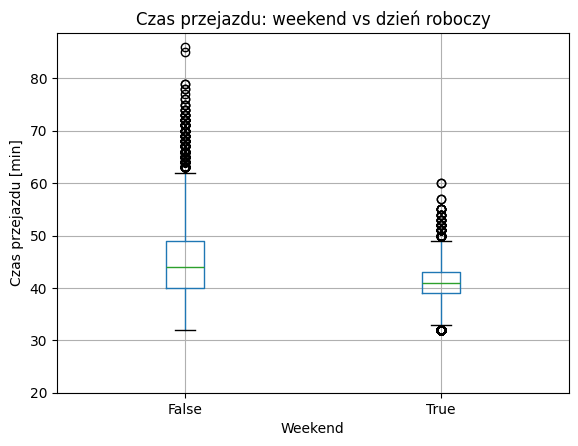

In [22]:
df.boxplot(column='Duration_Min', by='Is_Weekend')
plt.xlabel('Weekend')
plt.ylabel('Czas przejazdu [min]')
plt.title('Czas przejazdu: weekend vs dzień roboczy')
plt.suptitle('')
yticks = plt.yticks(range(20, 90, 10))
plt.show()

**Wniosek:** Pomiędzy weekendem a dniami roboczymi zgodnie z oczekiwaniami są widoczne różnice. Średni czas przejazdu w weekend to ok. 41 minut, a w tygodniu 44,5 minuty. Na powyższym boxplocie możemy zauważyć że również maksymalne czasy przejazdu w weeekend są widocznie niższe. 

---

## Podsumowanie wyników


1. Kierunek B staje się widocznie dłuższa od kierunku A jedynie od ok. 14:00 do 16:00, kiedy najwięcej osób wraca z Katowic. 

2. Temperatura okazuje się mieć znaczący wpływ na czas przejazdu. Wraz ze wzrostem temperatury czas przejazdu wzrasta. Może mieć na to wpływ większy ruch turystyczny gdy pogoda jest ładna lub generalny wzrost temperatury w okolicach popołudnia, gdy ruch naturalnie jest większy. 

3. W kierunku A najkrótszą i najbardziej przewidywalną trasą jest trasa 3 (przez Piekary Śląskie), natomiast w kierunku B sytuacja jest bardziej złożona: trasa 2 (przez Bytom) wygrywa przez większość doby, ale w godzinach 13:00–16:00 lepsza jest trasa 1 (przez Gliwice), która ma też znacznie mniejsze odchylenie standardowe

4. Godziny nocne (1:00-3:00) są najlepsze dla obu kierunków. Najgorsze to 15:00 oraz 16:00, natomiast w kierunku A także godziny poranne (6:00-9:00) wykazują znaczne wzrosty czasu przejazdu.

5. Weekend znacząco skraca czas przejazdu, średnio 41 min w weekend vs 44.5 min w tygodniu. Maksymalne czasy przejazdu w weekend są widocznie niższe.

## Wniosek ogólny

Czas przejazdu pomiędzy Tarnowskimi Górami i Katowicami jest bardzo mocno zależny od czynników takich jak godzina, dzień tygodnia, pogoda. Aby obniżyć swoje szanse na długi postój w korku warto dojeżdzać do Katowic przed godziną 6:00 lub po godzinie 9:00, natomiast wracać przed 14:00 lub dopiero po godzinie 16:00, kiedy korki są największe. Warto wziąć pod uwagę że wysoka temperatura także może wpływać na ruch w stronę Katowic. Jeśli naszym celem jest przebycie tej trasy w najkrótszym możliwym czasie, najlepszą opcją będą godziny nocne (ok. 1:00-3:00), lub w ciągu dnia - weekendy, gdzie średnia czasu przejazdu znacznie skraca się w porównaniu do dni roboczych. Jeśli chodzi o konkretne trasy, to te przez Pyrzowice oraz Siemianowice Śląskie praktycznie zawsze wykazują się dłuższym czasem przejazdu niż pozostałe trasy. W kierunku Katowic najlepszą trasą zazwyczaj będzie ta przez Piekary Śląskie, natomiast w kierunku Tarnowskich Gór często lepsza okaże się trasa przez Bytom, a w popołudniowych godzinach szczytu warto rozważyć drogę przez Gliwice. 